In [ ]:
 pip install pandas

In [ ]:
import pandas as pd

In [ ]:
import kagglehub
import csv
from pathlib import Path

# Download latest version
path = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")
print("Path to dataset files:", path)

DATA_DIR = Path(path)  # contains train/REAL, train/FAKE, test/REAL, test/FAKE
OUTPUT_CSV = Path("/content/manifest.csv")
IMAGE_EXTS = {".jpg", ".jpeg", ".png"}

def guess_label(p: Path):
    parts = [x.lower() for x in p.parts]
    if "real" in parts:
        return 0
    if "fake" in parts:
        return 1
    return None

def guess_split(p: Path):
    parts = [x.lower() for x in p.parts]
    if "train" in parts:
        return "train"
    if "test" in parts:
        return "test"
    return "unknown"

all_images = [p for p in DATA_DIR.rglob("*") if p.suffix.lower() in IMAGE_EXTS]
print(f"Found {len(all_images)} images under {DATA_DIR}\n")

rows, unknown = [], []
for img in all_images:
    label = guess_label(img)
    if label is None:
        unknown.append(img)
    else:
        rows.append((str(img), label, guess_split(img)))

real_count = sum(1 for _, l, _ in rows if l == 0)
fake_count = sum(1 for _, l, _ in rows if l == 1)
print(f"Auto-labeled: {real_count} real, {fake_count} fake, {len(unknown)} unknown")

with open(OUTPUT_CSV, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["image_path", "label", "split"])  # label: 0 = real, 1 = fake
    writer.writerows(rows)

print(f"Wrote manifest for {len(rows)} labeled images to {OUTPUT_CSV}")

Using Colab cache for faster access to the 'cifake-real-and-ai-generated-synthetic-images' dataset.
Path to dataset files: /kaggle/input/cifake-real-and-ai-generated-synthetic-images
Found 120000 images under /kaggle/input/cifake-real-and-ai-generated-synthetic-images

Auto-labeled: 60000 real, 60000 fake, 0 unknown
Wrote manifest for 120000 labeled images to /content/manifest.csv


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/manifest.csv')

In [ ]:
print('DataFrame Info:')
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   image_path  120000 non-null  object
 1   label       120000 non-null  int64 
 2   split       120000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB


In [ ]:
print('\nDataFrame Description:')
df.describe()


DataFrame Description:


,label
count,120000.000000
mean,0.500000
std,0.500002
min,0.000000
25%,0.000000
50%,0.500000
75%,1.000000
max,1.000000


In [ ]:
print('\nDataFrame Shape:')
print(df.shape)


DataFrame Shape:
(120000, 3)


In [ ]:
print('\nMissing Values:')
print(df.isnull().sum())


Missing Values:
image_path    0
label         0
split         0
dtype: int64


In [ ]:
print('\nDataFrame Headers:')
print(df.columns)


DataFrame Headers:
Index(['image_path', 'label', 'split'], dtype='object')


In [ ]:
!pip install transformers albumentations -q

In [ ]:
import albumentations as A
import numpy as np
import cv2
from PIL import Image

def resize_roundtrip(img_np, scale):
    h, w = img_np.shape[:2]
    small = cv2.resize(img_np, (max(1,int(w*scale)), max(1,int(h*scale))), interpolation=cv2.INTER_LINEAR)
    return cv2.resize(small, (w, h), interpolation=cv2.INTER_LINEAR)

def center_crop(img_np, frac):
    h, w = img_np.shape[:2]
    nh, nw = int(h*frac), int(w*frac)
    top, left = (h-nh)//2, (w-nw)//2
    return img_np[top:top+nh, left:left+nw]

PLAIN_FUNCS = {"clean", "resize_0.5", "resize_0.25", "crop_80"}

TRANSFORMS = {
    "clean": lambda img: img,
    "jpeg_90": A.ImageCompression(quality_range=(90,90), compression_type="jpeg", p=1.0),
    "jpeg_70": A.ImageCompression(quality_range=(70,70), compression_type="jpeg", p=1.0),
    "jpeg_50": A.ImageCompression(quality_range=(50,50), compression_type="jpeg", p=1.0),
    "jpeg_30": A.ImageCompression(quality_range=(30,30), compression_type="jpeg", p=1.0),
    "blur_0.5": A.GaussianBlur(sigma_limit=(0.5,0.5), blur_limit=0, p=1.0),
    "blur_1.0": A.GaussianBlur(sigma_limit=(1.0,1.0), blur_limit=0, p=1.0),
    "blur_2.0": A.GaussianBlur(sigma_limit=(2.0,2.0), blur_limit=0, p=1.0),
    "resize_0.5": lambda img: resize_roundtrip(img, 0.5),
    "resize_0.25": lambda img: resize_roundtrip(img, 0.25),
    "noise_0.02": A.GaussNoise(std_range=(0.02,0.02), p=1.0),
    "noise_0.05": A.GaussNoise(std_range=(0.05,0.05), p=1.0),
    "noise_0.10": A.GaussNoise(std_range=(0.10,0.10), p=1.0),
    "color_jitter": A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.0, p=1.0),
    "crop_80": lambda img: center_crop(img, 0.8),
}

def apply_transform(img_pil, name):
    img_np = np.array(img_pil)
    t = TRANSFORMS[name]
    out = t(img_np) if name in PLAIN_FUNCS else t(image=img_np)["image"]
    return Image.fromarray(out)

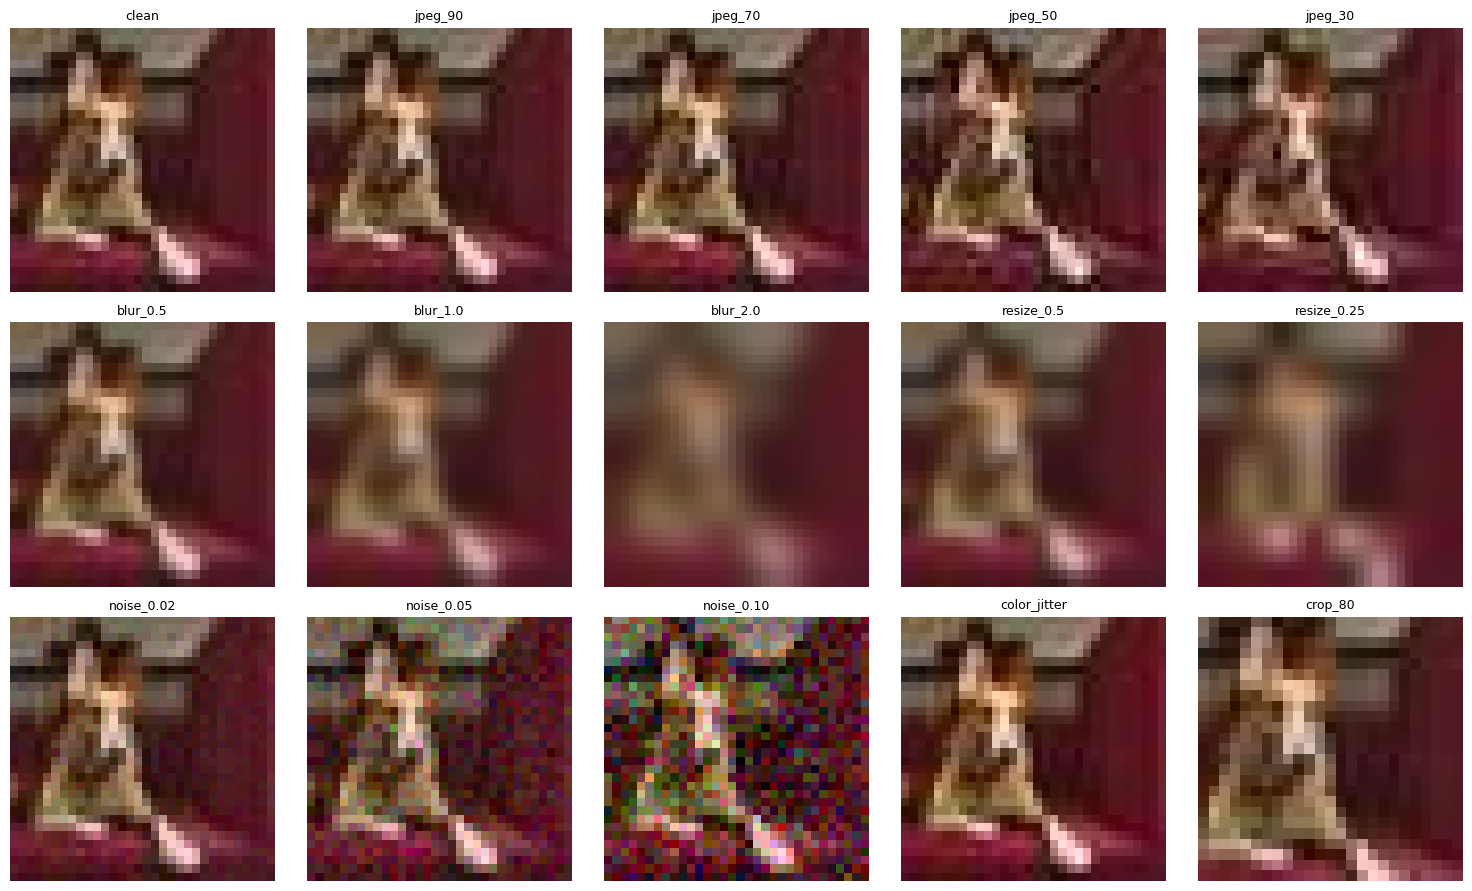

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

subset_df = pd.read_csv("/content/manifest.csv")
test_img = Image.open(subset_df.iloc[0]["image_path"]).convert("RGB")

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for ax, name in zip(axes.flat, TRANSFORMS.keys()):
    ax.imshow(apply_transform(test_img, name))
    ax.set_title(name, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
import torch
from transformers import AutoImageProcessor, AutoModel
from tqdm import tqdm
import numpy as np
import pandas as pd
from PIL import Image

# --- 0. Confirm environment before doing anything expensive ---
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if device == "cpu":
    print("WARNING: no GPU. Go to Runtime -> Change runtime type -> T4 GPU, "
          "then re-run every cell from the top (switching runtime wipes the session).")

# --- 1. Load the SUBSET manifest explicitly — don't rely on a leftover variable ---
subset_df = pd.read_csv("/content/manifest.csv")
print(f"Loaded {len(subset_df)} rows")
print(subset_df.groupby(["split", "label"]).size())

# --- 2. Load DINOv2 ---
processor = AutoImageProcessor.from_pretrained("facebook/dinov2-base")
dino = AutoModel.from_pretrained("facebook/dinov2-base").to(device).eval()

# --- 3. FFT feature (same as before) ---
def fft_feature_vector(img_pil, n_bins=32):
    gray = np.array(img_pil.convert("L"), dtype=np.float32)
    fshift = np.fft.fftshift(np.fft.fft2(gray))
    magnitude = np.log(np.abs(fshift) + 1e-8)
    h, w = magnitude.shape
    cy, cx = h // 2, w // 2
    y, x = np.indices((h, w))
    r = np.sqrt((x - cx) ** 2 + (y - cy) ** 2).astype(int)
    max_r = r.max()
    bin_edges = np.linspace(0, max_r, n_bins + 1)
    profile = np.zeros(n_bins)
    for i in range(n_bins):
        mask = (r >= bin_edges[i]) & (r < bin_edges[i + 1])
        if mask.sum() > 0:
            profile[i] = magnitude[mask].mean()
    return profile

# --- 4. Single-image version (kept for Steps 6/7 later, which need per-transform calls) ---
@torch.no_grad()
def embed_image(img_pil):
    inputs = processor(images=img_pil, return_tensors="pt").to(device)
    return dino(**inputs).last_hidden_state[:, 0].cpu().numpy().squeeze()

def get_fused_embedding(image_path, transform_name="clean", n_fft_bins=32):
    img = Image.open(image_path).convert("RGB")
    img = apply_transform(img, transform_name)
    dino_emb = embed_image(img)
    fft_feat = fft_feature_vector(img, n_bins=n_fft_bins)
    return np.concatenate([dino_emb, fft_feat])

# --- 5. FAST batched extraction for the bulk clean pass (this is what was timing out) ---
@torch.no_grad()
def embed_batch_dino(img_list):
    inputs = processor(images=img_list, return_tensors="pt").to(device)
    return dino(**inputs).last_hidden_state[:, 0].cpu().numpy()  # (B, 768)

BATCH_SIZE = 32
image_paths = subset_df["image_path"].tolist()
labels = subset_df["label"].to_numpy()
splits = subset_df["split"].to_numpy()

all_embeddings = []
for i in tqdm(range(0, len(image_paths), BATCH_SIZE)):
    batch_paths = image_paths[i:i + BATCH_SIZE]
    batch_imgs = [Image.open(p).convert("RGB") for p in batch_paths]

    dino_feats = embed_batch_dino(batch_imgs)                                # (B, 768)
    fft_feats = np.stack([fft_feature_vector(img) for img in batch_imgs])    # (B, 32)
    fused = np.concatenate([dino_feats, fft_feats], axis=1)                  # (B, 800)
    all_embeddings.append(fused)

embeddings = np.concatenate(all_embeddings, axis=0)
np.savez("/content/embeddings_fused.npz", embeddings=embeddings, labels=labels, splits=splits)
print("Saved:", embeddings.shape)

Device: cuda
Loaded 120000 rows
split  label
test   0        10000
       1        10000
train  0        50000
       1        50000
dtype: int64


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

100%|██████████| 3750/3750 [41:28<00:00,  1.51it/s]


Saved: (120000, 800)


In [ ]:
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, roc_auc_score

data = np.load("/content/embeddings_fused.npz", allow_pickle=True)
X, y, splits = data["embeddings"], data["labels"], data["splits"]

X_train, y_train = X[splits == "train"], y[splits == "train"]
X_test, y_test = X[splits == "test"], y[splits == "test"]
print(f"train: {X_train.shape}, test: {X_test.shape}")

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

class Head(nn.Module):
    def __init__(self, in_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(0.2), nn.Linear(hidden, 1))
    def forward(self, x):
        return self.net(x)

head = Head(X.shape[1])
optimizer = optim.Adam(head.parameters(), lr=1e-3)
loss_fn = nn.BCEWithLogitsLoss()

for epoch in range(30):
    head.train()
    optimizer.zero_grad()
    loss = loss_fn(head(X_train_t), y_train_t)
    loss.backward()
    optimizer.step()
    if epoch % 5 == 0:
        head.eval()
        with torch.no_grad():
            preds = torch.sigmoid(head(X_test_t)).numpy().squeeze()
        print(f"epoch {epoch}: loss {loss.item():.4f}, acc {accuracy_score(y_test, preds>0.5):.4f}, AUC {roc_auc_score(y_test, preds):.4f}")

torch.save(head.state_dict(), "/content/head_fused.pt")

train: (100000, 800), test: (20000, 800)
epoch 0: loss 0.7004, acc 0.6864, AUC 0.8293
epoch 5: loss 0.3616, acc 0.8750, AUC 0.9531
epoch 10: loss 0.2445, acc 0.9073, AUC 0.9709
epoch 15: loss 0.2038, acc 0.9237, AUC 0.9781
epoch 20: loss 0.1790, acc 0.9327, AUC 0.9824
epoch 25: loss 0.1617, acc 0.9388, AUC 0.9853


In [ ]:
# small, class-balanced sample just for the robustness eval — separate from training
df = pd.read_csv("/content/manifest.csv")
test_df = df[df["split"] == "test"]
eval_df = test_df.groupby("label", group_keys=False).apply(lambda g: g.sample(n=min(500, len(g)), random_state=42))
print(eval_df.groupby("label").size())  # ~500/class = 1000 images

@torch.no_grad()
def get_fused_embeddings_batch(image_paths, transform_name="clean", batch_size=32):
    all_embeds = []
    for i in range(0, len(image_paths), batch_size):
        batch = image_paths[i:i+batch_size]
        imgs = [apply_transform(Image.open(p).convert("RGB"), transform_name) for p in batch]
        dino_feats = embed_batch_dino(imgs)
        fft_feats = np.stack([fft_feature_vector(img) for img in imgs])
        all_embeds.append(np.concatenate([dino_feats, fft_feats], axis=1))
    return np.concatenate(all_embeds, axis=0)

eval_paths = eval_df["image_path"].tolist()
eval_labels = eval_df["label"].to_numpy()
results = {}

for name in TRANSFORMS.keys():
    embs = get_fused_embeddings_batch(eval_paths, transform_name=name)
    head.eval()
    with torch.no_grad():
        preds = torch.sigmoid(head(torch.tensor(embs, dtype=torch.float32))).numpy().squeeze()
    results[name] = {"accuracy": accuracy_score(eval_labels, preds>0.5), "auc": roc_auc_score(eval_labels, preds)}
    print(name, results[name])

results_df = pd.DataFrame(results).T
results_df.to_csv("/content/robustness_table_fused.csv")
results_df

/tmp/ipykernel_1096/1370969631.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  eval_df = test_df.groupby("label", group_keys=False).apply(lambda g: g.sample(n=min(500, len(g)), random_state=42))


label
0    500
1    500
dtype: int64
clean {'accuracy': 0.946, 'auc': np.float64(0.986396)}
jpeg_90 {'accuracy': 0.94, 'auc': np.float64(0.9859199999999999)}
jpeg_70 {'accuracy': 0.941, 'auc': np.float64(0.986412)}
jpeg_50 {'accuracy': 0.89, 'auc': np.float64(0.9732240000000001)}
jpeg_30 {'accuracy': 0.862, 'auc': np.float64(0.962528)}
blur_0.5 {'accuracy': 0.91, 'auc': np.float64(0.981016)}
blur_1.0 {'accuracy': 0.718, 'auc': np.float64(0.943468)}
blur_2.0 {'accuracy': 0.588, 'auc': np.float64(0.861656)}
resize_0.5 {'accuracy': 0.682, 'auc': np.float64(0.931608)}
resize_0.25 {'accuracy': 0.553, 'auc': np.float64(0.8575799999999999)}
noise_0.02 {'accuracy': 0.877, 'auc': np.float64(0.971016)}
noise_0.05 {'accuracy': 0.739, 'auc': np.float64(0.948496)}
noise_0.10 {'accuracy': 0.591, 'auc': np.float64(0.9001520000000001)}
color_jitter {'accuracy': 0.948, 'auc': np.float64(0.9862199999999999)}
crop_80 {'accuracy': 0.852, 'auc': np.float64(0.9667279999999999)}


,accuracy,auc
clean,0.946,0.986396
jpeg_90,0.940,0.985920
jpeg_70,0.941,0.986412
jpeg_50,0.890,0.973224
jpeg_30,0.862,0.962528
blur_0.5,0.910,0.981016
blur_1.0,0.718,0.943468
blur_2.0,0.588,0.861656
resize_0.5,0.682,0.931608
resize_0.25,0.553,0.857580


In [ ]:
from sklearn.metrics import confusion_matrix

def diagnose_transform(name):
    embs = get_fused_embeddings_batch(eval_paths, transform_name=name)
    with torch.no_grad():
        preds = torch.sigmoid(head(torch.tensor(embs, dtype=torch.float32))).numpy().squeeze()
    print(f"\n{name}")
    print("confusion matrix [rows=true real/fake, cols=pred real/fake]:")
    print(confusion_matrix(eval_labels, preds > 0.5))
    print(f"mean predicted P(fake) for TRUE real images: {preds[eval_labels==0].mean():.3f}")
    print(f"mean predicted P(fake) for TRUE fake images: {preds[eval_labels==1].mean():.3f}")

for name in ["clean", "blur_2.0", "resize_0.25", "noise_0.10"]:
    diagnose_transform(name)


clean
confusion matrix [rows=true real/fake, cols=pred real/fake]:
[[464  36]
 [ 18 482]]
mean predicted P(fake) for TRUE real images: 0.108
mean predicted P(fake) for TRUE fake images: 0.921

blur_2.0
confusion matrix [rows=true real/fake, cols=pred real/fake]:
[[494   6]
 [406  94]]
mean predicted P(fake) for TRUE real images: 0.027
mean predicted P(fake) for TRUE fake images: 0.226

resize_0.25
confusion matrix [rows=true real/fake, cols=pred real/fake]:
[[496   4]
 [443  57]]
mean predicted P(fake) for TRUE real images: 0.017
mean predicted P(fake) for TRUE fake images: 0.160

noise_0.10
confusion matrix [rows=true real/fake, cols=pred real/fake]:
[[500   0]
 [413  87]]
mean predicted P(fake) for TRUE real images: 0.010
mean predicted P(fake) for TRUE fake images: 0.223


"Under blur (σ=2.0), 4× downscaling, and heavy noise (σ=0.10), the model's failures are not symmetric: false-positive rate on real images actually decreases (7.2% → 0%), while true-positive rate on fake images collapses (96.4% → 11–19%). This indicates the model isn't generally confused by these corruptions — it specifically loses the ability to detect fakes, since blur/downscaling/noise suppress the high-frequency generation artifacts (upsampling patterns, fine texture) the FFT and DINOv2 features rely on. This is a materially riskier failure mode than random misclassification, since AI-generated content becomes more likely to pass as authentic exactly when it's most likely to be encountered in the wild (re-shared, re-compressed, low-quality)."


In [ ]:
import shutil, os
from pathlib import Path
import pandas as pd

df = pd.read_csv("/content/manifest.csv")
test_sample = df[df["split"] == "test"].sample(20, random_state=1)

test_folder = "/content/my_test_images"
os.makedirs(test_folder, exist_ok=True)

copy_records = []
for i, (_, row) in enumerate(test_sample.iterrows()):
    ext = Path(row["image_path"]).suffix
    dest_name = f"{i:03d}_{'fake' if row['label']==1 else 'real'}{ext}"
    dest_path = os.path.join(test_folder, dest_name)
    shutil.copy(row["image_path"], dest_path)
    copy_records.append({"image_path": dest_path, "label": row["label"]})

ground_truth = pd.DataFrame(copy_records)
ground_truth.to_csv("/content/my_test_images_labels.csv", index=False)
print(f"Copied {len(ground_truth)} uniquely-named images")

Copied 20 uniquely-named images


In [ ]:
!python inference.py --image_dir /content/my_test_images --weights /content/head_fused.pt --output /content/predictions.json

Device: cuda
Loading DINOv2 (facebook/dinov2-base)...
Loading weights: 100% 223/223 [00:00<00:00, 5814.92it/s]
Loading classifier head from /content/head_fused.pt...
Found 40 images under /content/my_test_images
  processed 32/40
  processed 40/40

Wrote 40 predictions to /content/predictions.json


In [ ]:
import json
with open("/content/predictions.json") as f:
    preds_df = pd.DataFrame(json.load(f))

merged = preds_df.merge(ground_truth, on="image_path")
merged["predicted_label"] = (merged["pred"] > 0.5).astype(int)
merged["correct"] = merged["predicted_label"] == merged["label"]

print(merged[["image_path", "label", "pred", "predicted_label", "correct"]])
print(f"\nAccuracy on this sample: {merged['correct'].mean():.2%}")

                              image_path  label      pred  predicted_label  \
0   /content/my_test_images/000_real.jpg      0  0.000376                0   
1   /content/my_test_images/001_real.jpg      0  0.020637                0   
2   /content/my_test_images/002_fake.jpg      1  0.997516                1   
3   /content/my_test_images/003_real.jpg      0  0.005468                0   
4   /content/my_test_images/004_fake.jpg      1  0.998338                1   
5   /content/my_test_images/005_real.jpg      0  0.000985                0   
6   /content/my_test_images/006_real.jpg      0  0.844187                1   
7   /content/my_test_images/007_real.jpg      0  0.047730                0   
8   /content/my_test_images/008_fake.jpg      1  0.998176                1   
9   /content/my_test_images/009_fake.jpg      1  0.998198                1   
10  /content/my_test_images/010_fake.jpg      1  0.275987                0   
11  /content/my_test_images/011_real.jpg      0  0.001194       

from google.colab import files
import matplotlib.pyplot as plt

def predict_uploaded_image():
    uploaded = files.upload()  # opens a file picker in the browser

    for filename in uploaded.keys():
        img = Image.open(filename).convert("RGB")

        dino_emb = embed_image(img)
        fft_feat = fft_feature_vector(img)
        fused = np.concatenate([dino_emb, fft_feat])

        with torch.no_grad():
            pred = torch.sigmoid(head(torch.tensor(fused, dtype=torch.float32).unsqueeze(0))).item()

        label = "AI-GENERATED" if pred > 0.5 else "REAL"
        confidence = pred if pred > 0.5 else 1 - pred

        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{label}  (confidence: {confidence:.1%})")
        plt.show()
        print(f"Raw model output — P(fake): {pred:.4f}")

predict_uploaded_image()